# IND320 Project Work – Part 1

In this notebook, I will prepare and explore the Norwegian reservoir
dataset before using the same data in my Streamlit app.

## 1. Reading the reservoir data and imoprts

The CSV file is stored in the `data` folder, while this notebook is stored
in `notebooks`. I use a relative path instead of the full path on my
computer so the notebook can still find the data when the repository is
downloaded or cloned by someone else.

In [1]:
#Imports
import pandas as pd
from IPython.display import display

In [3]:
# The two dots take me one folder back from notebooks/.
# From there, I enter the data folder and read the CSV file.
reservoirs = pd.read_csv("../data/reservoirs.csv")

# The complete dataset is too large to print in the notebook.
# I therefore show its size and the first five rows to check that it loaded correctly.
print(f"The dataset contains {reservoirs.shape[0]:,} rows and {reservoirs.shape[1]} columns.")

reservoirs.head()

# I create a small overview of the original headers, their data types,
# and one example value. This helps me understand what each column represents
# before I decide on clearer English names.
header_review = pd.DataFrame({
    "original_header": reservoirs.columns,
    "data_type": reservoirs.dtypes.astype(str).values,
    "example_value": [
        reservoirs[column].iloc[0]
        for column in reservoirs.columns
    ]
})

header_review

The dataset contains 14,877 rows and 11 columns.


,original_header,data_type,example_value
0,dato_Id,str,1995-09-03
1,omrType,str,EL
2,omrnr,int64,4
3,iso_aar,int64,1995
4,iso_uke,int64,35
5,fyllingsgrad,float64,0.944721
6,kapasitet_TWh,float64,21.079208
7,fylling_TWh,float64,19.913979
8,neste_Publiseringsdato,str,0001-01-01T00:00:00
9,fyllingsgrad_forrige_uke,float64,0.936888


In [4]:
# I rename the original Norwegian headers to make the dataset easier to
# understand when I create tables, plots, and the Streamlit application.
english_column_names = {
    "dato_Id": "observation_date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_fraction",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_fraction",
    "endring_fyllingsgrad": "weekly_filling_change"
}

reservoirs = reservoirs.rename(columns=english_column_names)

# I print the updated headers to check that every column was renamed correctly.
print(reservoirs.columns.tolist())

['observation_date', 'area_type', 'area_number', 'iso_year', 'iso_week', 'filling_fraction', 'capacity_twh', 'stored_energy_twh', 'next_publication_date', 'previous_week_filling_fraction', 'weekly_filling_change']


### Explanation of the renamed columns

I renamed the original Norwegian headers to make their meanings clearer and to
use consistent English names throughout the notebook and Streamlit application.

- **observation_date:** The date on which the reservoir level was recorded.
- **area_type:** The geographical grouping used by NVE. `EL` represents an
  electricity price area, `VASS` represents a watercourse region, and `NO`
  represents Norway as a whole.
- **area_number:** Identifies the particular area within the selected area type.
  For example, `EL` combined with area number `1` represents electricity price
  area NO1.
- **iso_year:** The year according to the ISO calendar.
- **iso_week:** The week number according to the ISO calendar.
- **filling_fraction:** The proportion of the total reservoir capacity currently
  filled. For example, `0.80` means that the reservoirs are 80% full.
- **capacity_twh:** The maximum energy-storage capacity of the reservoirs,
  measured in terawatt-hours (TWh).
- **stored_energy_twh:** The amount of energy currently stored in the reservoirs,
  measured in TWh.
- **next_publication_date:** The planned date and time for NVE's next data
  publication.
- **previous_week_filling_fraction:** The filling fraction recorded during the
  previous week.
- **weekly_filling_change:** The change in filling fraction compared with the
  previous week. For example, `0.01` corresponds to an increase of one
  percentage point.

The area codes have not been renamed because they are official identifiers used
by NVE. Their meanings were verified using the
[NVE reservoir-statistics API](https://biapi.nve.no/magasinstatistikk/swagger/index.html)
and its
[area documentation](https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk/HentOmr%C3%A5der).

In [5]:
# Printing the entire dataset would produce thousands of rows, so I show its
# dimensions and the first ten rows as a useful preview instead.
print(
    f"The reservoir dataset contains {reservoirs.shape[0]:,} rows "
    f"and {reservoirs.shape[1]} columns."
)

display(reservoirs.head(10))

The reservoir dataset contains 14,877 rows and 11 columns.


,observation_date,area_type,area_number,iso_year,iso_week,filling_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_fraction,weekly_filling_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


In [6]:
# The CSV is not arranged chronologically, so I find the earliest and latest
# dates and display every area recorded on those two dates.
first_date = reservoirs["observation_date"].min()
last_date = reservoirs["observation_date"].max()

print(f"First observation date: {first_date}")
display(
    reservoirs[reservoirs["observation_date"] == first_date]
    .sort_values(["area_type", "area_number"])
)

print(f"Latest observation date: {last_date}")
display(
    reservoirs[reservoirs["observation_date"] == last_date]
    .sort_values(["area_type", "area_number"])
)

First observation date: 1995-01-08


,observation_date,area_type,area_number,iso_year,iso_week,filling_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_fraction,weekly_filling_change
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
8501,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
14162,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,0001-01-01T00:00:00,0.798825,-0.162787
11380,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,0001-01-01T00:00:00,0.744693,-0.135837
11198,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,0001-01-01T00:00:00,0.661432,-0.094525


Latest observation date: 2026-09-06


,observation_date,area_type,area_number,iso_year,iso_week,filling_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_fraction,weekly_filling_change
8260,2026-09-06,EL,1,2026,36,0.725045,6.003264,4.352634,2026-09-16T13:00:00,0.716472,0.008573
8264,2026-09-06,EL,2,2026,36,0.460863,34.043590,15.689445,2026-09-16T13:00:00,0.458999,0.001865
8262,2026-09-06,EL,3,2026,36,0.632579,8.920932,5.643190,2026-09-16T13:00:00,0.627002,0.005577
8263,2026-09-06,EL,4,2026,36,0.902762,21.079208,19.029512,2026-09-16T13:00:00,0.906918,-0.004156
8261,2026-09-06,EL,5,2026,36,0.638898,17.390587,11.110812,2026-09-16T13:00:00,0.635173,0.003725
9917,2026-09-06,NO,0,2026,36,0.636054,87.437580,55.615055,2026-09-16T13:00:00,0.634421,0.001633
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14876,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16T13:00:00,0.514423,0.002555
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389


### First and latest observations

The original row order is not chronological, so displaying the first rows would
not necessarily show the beginning of the time series. I therefore display all
area records for the earliest and latest observation dates. This gives a more
useful picture of the time period covered by the dataset and the geographical
groups recorded each week.

In [7]:
# I create one compact summary showing the data type, number of missing values,
# and number of unique values in every column.
column_summary = pd.DataFrame({
    "data_type": reservoirs.dtypes.astype(str),
    "missing_values": reservoirs.isna().sum(),
    "unique_values": reservoirs.nunique()
})

print(
    f"The dataset contains {reservoirs.shape[0]:,} rows and "
    f"{reservoirs.shape[1]} columns."
)
print(f"Completely duplicated rows: {reservoirs.duplicated().sum()}")

display(column_summary)

# This table shows which area numbers belong to each official NVE area type.
display(pd.crosstab(
    reservoirs["area_type"],
    reservoirs["area_number"],
    margins=True
))

The dataset contains 14,877 rows and 11 columns.
Completely duplicated rows: 0


,data_type,missing_values,unique_values
observation_date,str,0,1653
area_type,str,0,3
area_number,int64,0,6
iso_year,int64,0,32
iso_week,int64,0,53
filling_fraction,float64,0,14868
capacity_twh,float64,0,9
stored_energy_twh,float64,0,14871
next_publication_date,str,0,396
previous_week_filling_fraction,float64,0,14868


area_number,0,1,2,3,4,5,All
area_type,,,,,,,
EL,0,1653,1653,1653,1653,1653,8265
NO,1653,0,0,0,0,0,1653
VASS,0,1653,1653,1653,0,0,4959
All,1653,3306,3306,3306,1653,1653,14877


In [8]:
# Pandas only counts formally missing values such as NaN or None.
# I count the unusual publication-date placeholder separately because it is
# present as text even though it does not represent a real publication date.
placeholder_date = "0001-01-01T00:00:00"

column_summary = pd.DataFrame({
    "data_type": reservoirs.dtypes.astype(str),
    "pandas_missing_values": reservoirs.isna().sum(),
    "unique_values": reservoirs.nunique()
})

column_summary["placeholder_values"] = 0
column_summary.loc["next_publication_date", "placeholder_values"] = (
    reservoirs["next_publication_date"] == placeholder_date
).sum()

display(column_summary)

,data_type,pandas_missing_values,unique_values,placeholder_values
observation_date,str,0,1653,0
area_type,str,0,3,0
area_number,int64,0,6,0
iso_year,int64,0,32,0
iso_week,int64,0,53,0
filling_fraction,float64,0,14868,0
capacity_twh,float64,0,9,0
stored_energy_twh,float64,0,14871,0
next_publication_date,str,0,396,11322
previous_week_filling_fraction,float64,0,14868,0


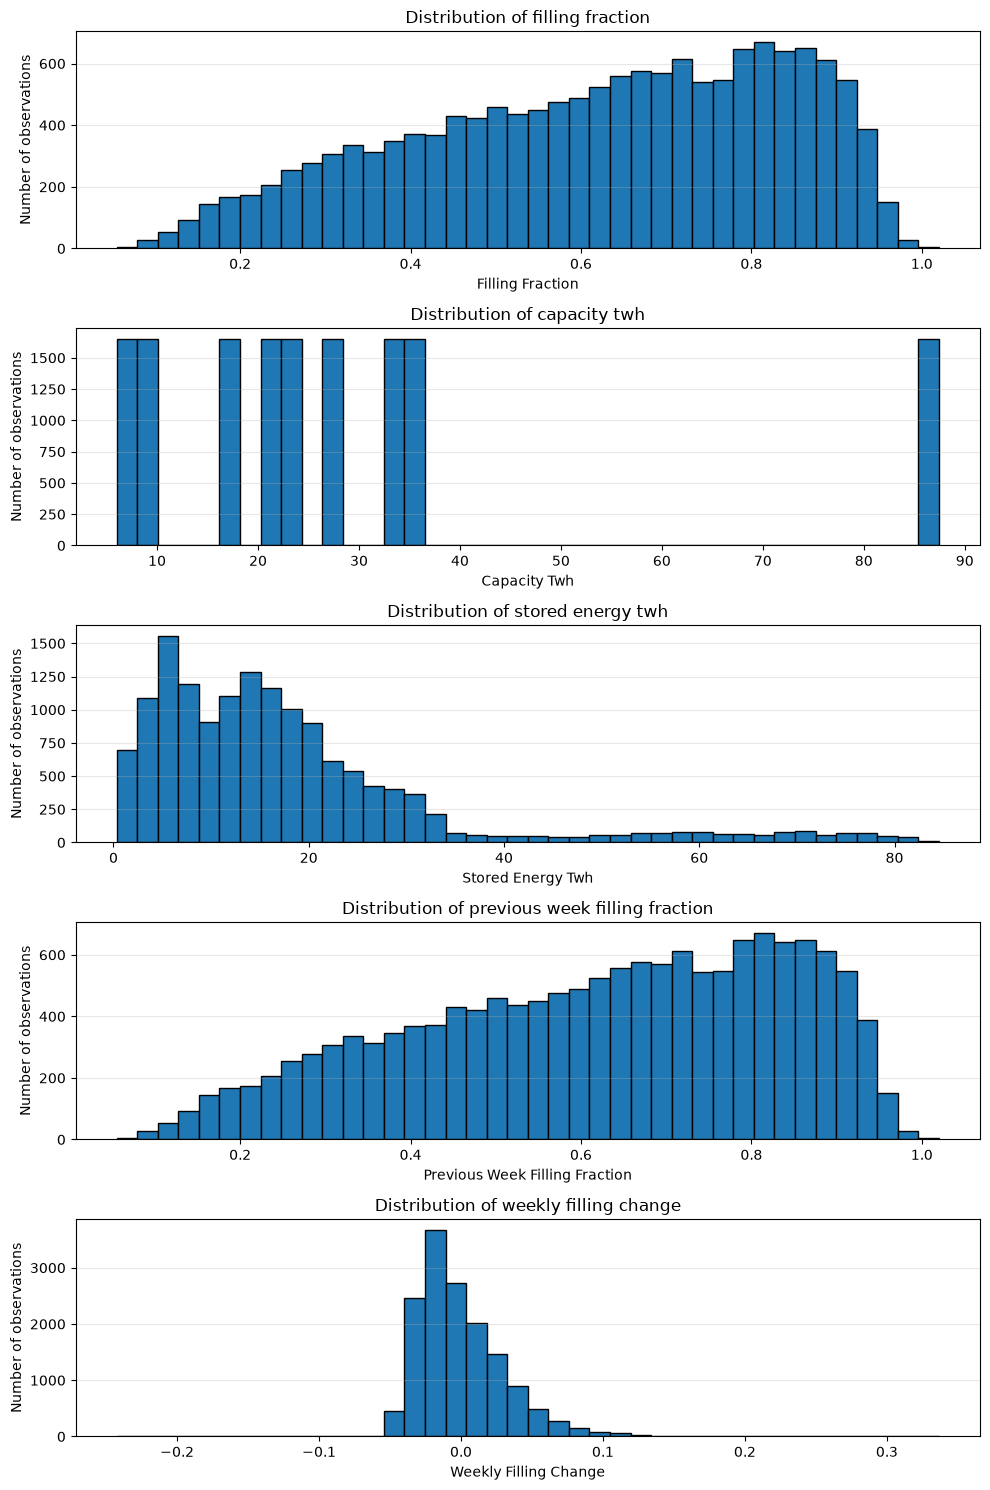

In [9]:
import matplotlib.pyplot as plt

# I only include actual measurements here. Identifiers such as area number,
# ISO year, and ISO week would not be useful in this placeholder check.
measurement_columns = [
    "filling_fraction",
    "capacity_twh",
    "stored_energy_twh",
    "previous_week_filling_fraction",
    "weekly_filling_change"
]

fig, axes = plt.subplots(
    nrows=len(measurement_columns),
    ncols=1,
    figsize=(10, 15)
)

# A numerical placeholder would normally appear as a large isolated spike,
# often at zero or far outside the range of the real observations.
for axis, column in zip(axes, measurement_columns):
    axis.hist(
        reservoirs[column],
        bins=40,
        edgecolor="black"
    )
    axis.set_title(f"Distribution of {column.replace('_', ' ')}")
    axis.set_xlabel(column.replace("_", " ").title())
    axis.set_ylabel("Number of observations")
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

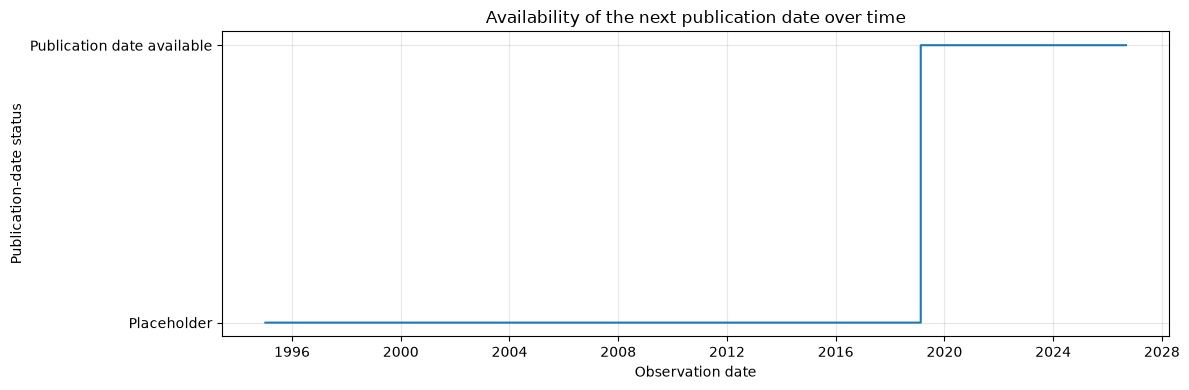

In [10]:
# The same publication date is repeated for all nine areas in each week,
# so I keep one record per observation date before creating the plot.
publication_availability = reservoirs[
    ["observation_date", "next_publication_date"]
].drop_duplicates("observation_date").copy()

publication_availability["observation_date"] = pd.to_datetime(
    publication_availability["observation_date"]
)

publication_availability["date_available"] = (
    publication_availability["next_publication_date"]
    != "0001-01-01T00:00:00"
)

publication_availability = publication_availability.sort_values(
    "observation_date"
)

plt.figure(figsize=(12, 4))
plt.step(
    publication_availability["observation_date"],
    publication_availability["date_available"].astype(int),
    where="post"
)

plt.yticks(
    [0, 1],
    ["Placeholder", "Publication date available"]
)
plt.xlabel("Observation date")
plt.ylabel("Publication-date status")
plt.title("Availability of the next publication date over time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Missing values and placeholder dates

Pandas reports no missing values because every cell contains a stored value.
However, this does not necessarily mean that every value contains useful
information.

The `next_publication_date` column contains the value
`0001-01-01T00:00:00` in 11,322 rows. Pandas treats this as an ordinary string,
so it is not included when `isna()` counts missing values. The date is the
minimum and default `DateTime` value used by .NET, which suggests that the field
was left uninitialized when no publication date was available. It should
therefore be understood as a placeholder rather than a genuine date.

NVE documents the column as the next publication date, but its API
documentation does not explicitly explain the placeholder. I have therefore
kept the original values unchanged and counted them separately instead of
silently replacing them. If the column is used later in the analysis or
Streamlit application, the placeholder can be converted to a missing value or
displayed as `Not available`.

I also checked whether other columns might contain artificial values used in
place of missing data. The numerical distributions do not show any repeated
extreme values such as `-999` or unexpected zeros. The measurement columns are
also internally consistent: stored energy corresponds to capacity multiplied
by filling fraction, and weekly change corresponds to the difference between
the current and previous filling fractions.

Two filling fractions are slightly above 1.0, meaning slightly above 100%.
These values may require further investigation, but they do not resemble
placeholders because they are not repeated and the related energy values remain
mathematically consistent. I therefore kept them unchanged.

Based on these checks, `0001-01-01T00:00:00` is the only clear placeholder in
the dataset. It appears throughout the older part of the time series and should
be interpreted as an unavailable next publication date rather than an actual
date.

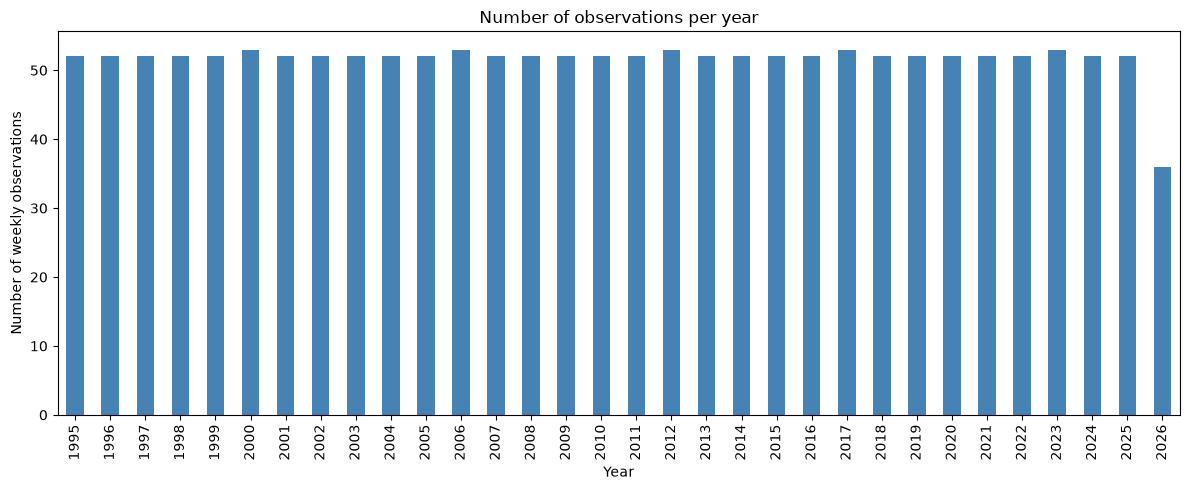

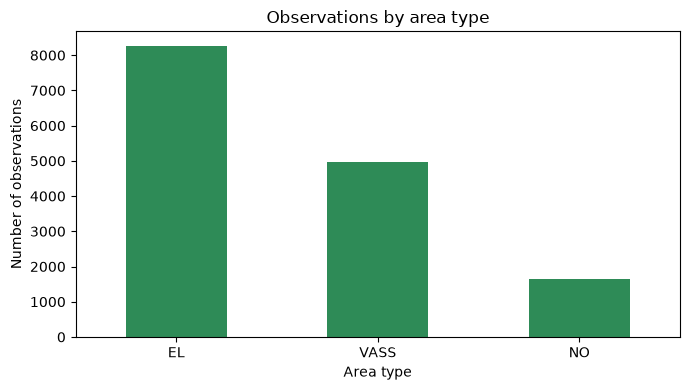

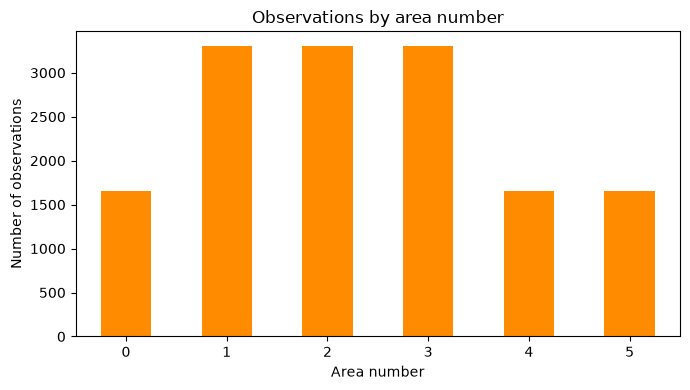

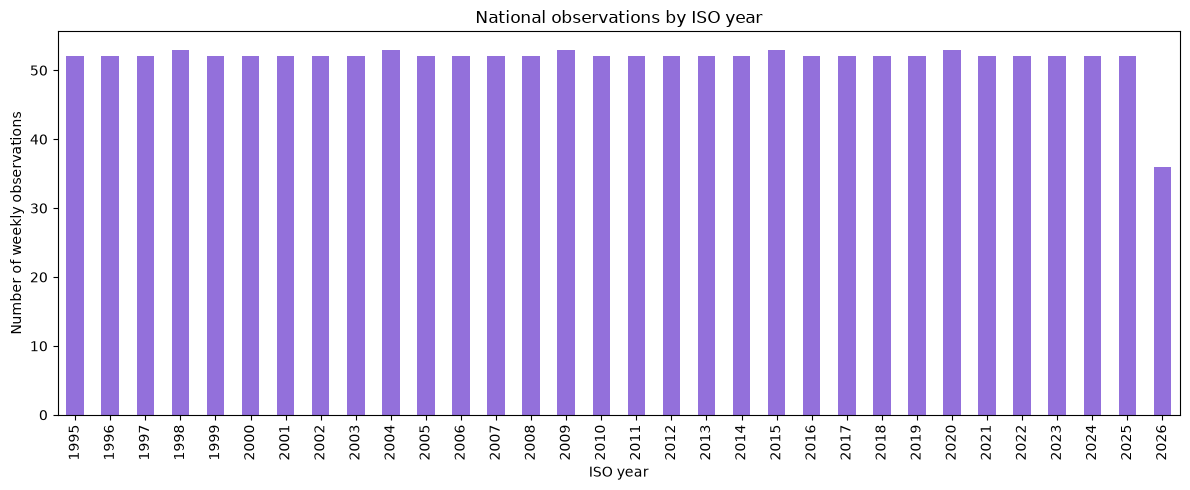

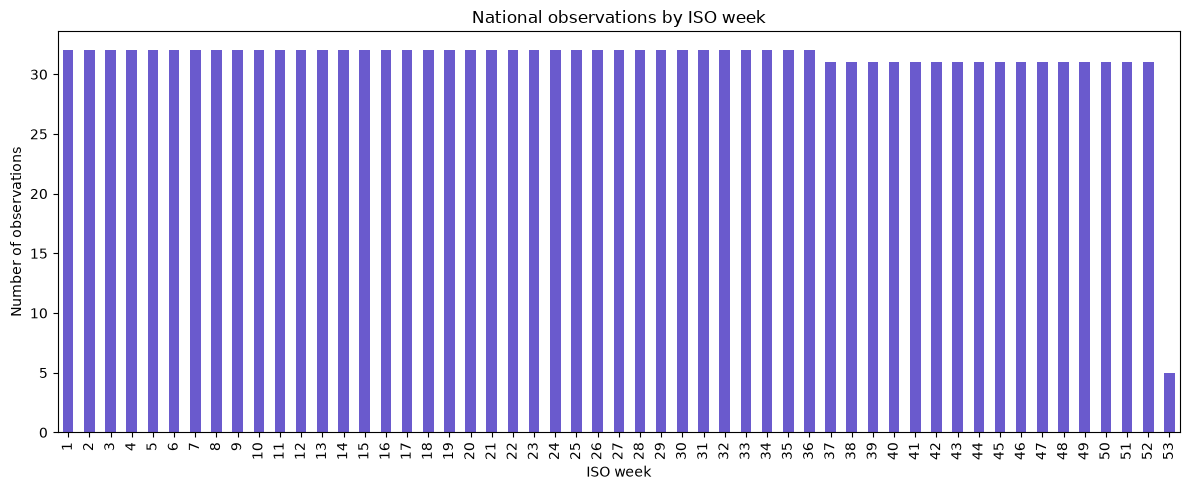

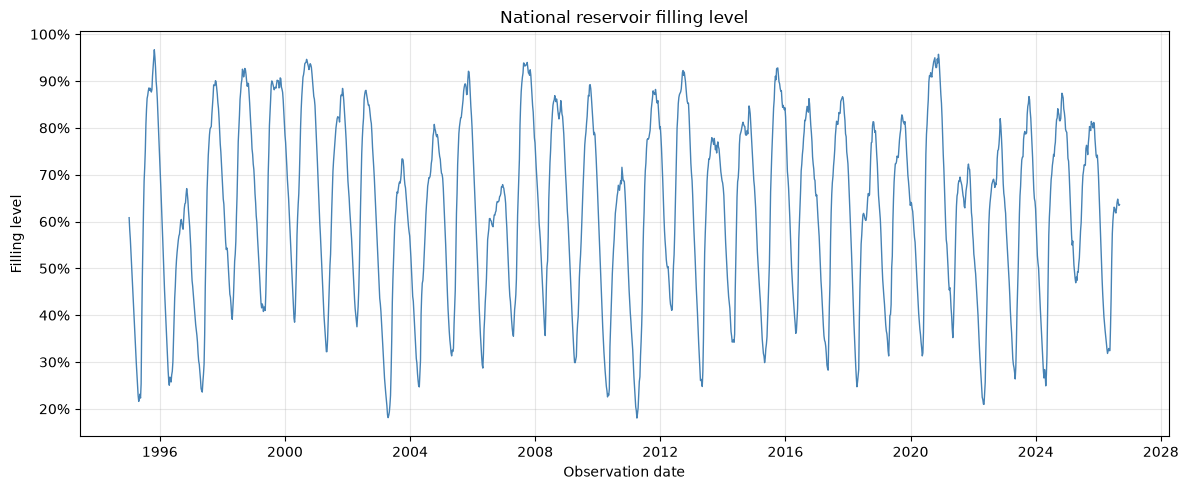

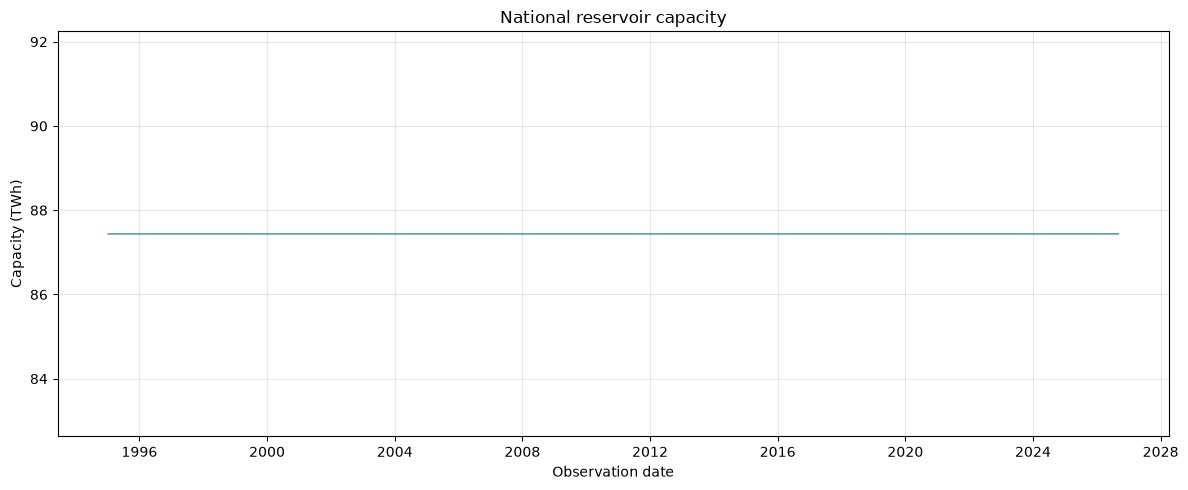

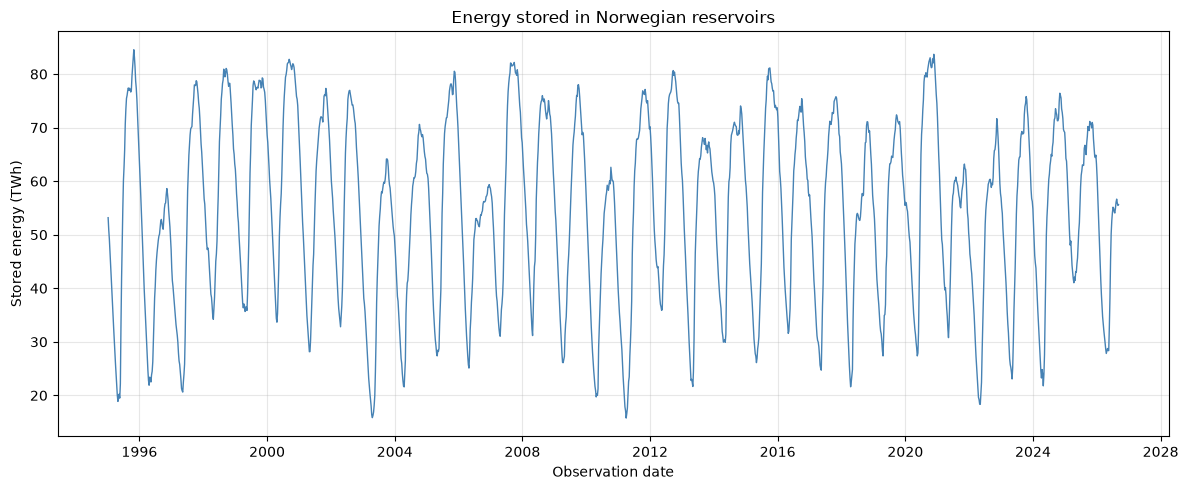

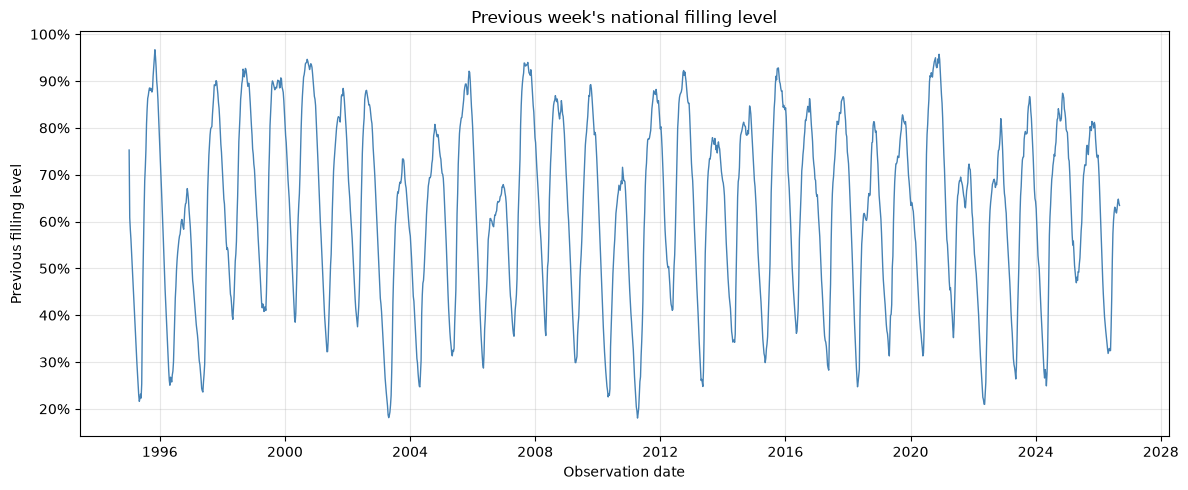

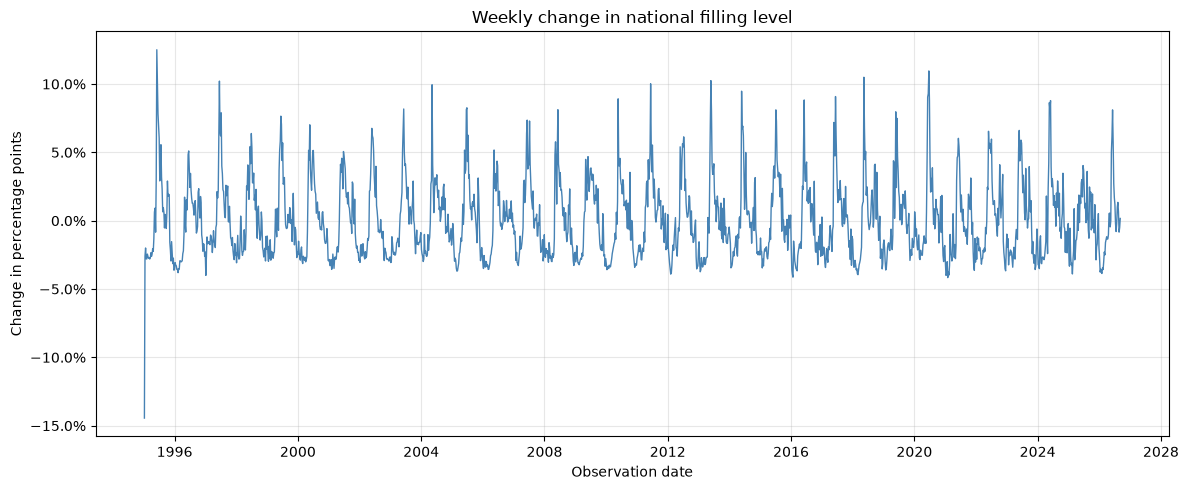

In [13]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# I create a separate copy for plotting so that converting the date does not
# change the original imported dataset.
plot_data = reservoirs.copy()

plot_data["observation_date"] = pd.to_datetime(
    plot_data["observation_date"]
)

# The dataset contains several overlapping geographical groupings. I use the
# national total for the time-series plots so that each date appears only once.
national_data = (
    plot_data[plot_data["area_type"] == "NO"]
    .sort_values("observation_date")
)

# observation_date: number of national observations recorded per year
observations_per_year = (
    national_data["observation_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

observations_per_year.plot(
    kind="bar",
    figsize=(12, 5),
    color="steelblue"
)
plt.title("Number of observations per year")
plt.xlabel("Year")
plt.ylabel("Number of weekly observations")
plt.tight_layout()
plt.show()


# area_type: number of rows belonging to each geographical grouping
reservoirs["area_type"].value_counts().plot(
    kind="bar",
    figsize=(7, 4),
    color="seagreen"
)
plt.title("Observations by area type")
plt.xlabel("Area type")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# area_number: area numbers are reused across different area types
reservoirs["area_number"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4),
    color="darkorange"
)
plt.title("Observations by area number")
plt.xlabel("Area number")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# iso_year: number of national observations in each ISO year
national_data["iso_year"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5),
    color="mediumpurple"
)
plt.title("National observations by ISO year")
plt.xlabel("ISO year")
plt.ylabel("Number of weekly observations")
plt.tight_layout()
plt.show()


# iso_week: frequency of the different ISO week numbers
national_data["iso_week"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5),
    color="slateblue"
)
plt.title("National observations by ISO week")
plt.xlabel("ISO week")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

# Each measurement gets its own plot because the columns use different units
# and scales. The fraction columns are formatted as percentages without
# changing their underlying values.
measurement_plots = {
    "filling_fraction": {
        "title": "National reservoir filling level",
        "ylabel": "Filling level",
        "percentage": True
    },
    "capacity_twh": {
        "title": "National reservoir capacity",
        "ylabel": "Capacity (TWh)",
        "percentage": False
    },
    "stored_energy_twh": {
        "title": "Energy stored in Norwegian reservoirs",
        "ylabel": "Stored energy (TWh)",
        "percentage": False
    },
    "previous_week_filling_fraction": {
        "title": "Previous week's national filling level",
        "ylabel": "Previous filling level",
        "percentage": True
    },
    "weekly_filling_change": {
        "title": "Weekly change in national filling level",
        "ylabel": "Change in percentage points",
        "percentage": True
    }
}

for column, settings in measurement_plots.items():
    fig, axis = plt.subplots(figsize=(12, 5))

    axis.plot(
        national_data["observation_date"],
        national_data[column],
        color="steelblue",
        linewidth=1
    )

    axis.set_title(settings["title"])
    axis.set_xlabel("Observation date")
    axis.set_ylabel(settings["ylabel"])
    axis.grid(alpha=0.3)

    if settings["percentage"]:
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))

    plt.tight_layout()
    plt.show()